In [5]:
# ==========================================
#  Setup and Environment Check
# ==========================================
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, random, gc, warnings
warnings.filterwarnings("ignore")


print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


TensorFlow version: 2.18.0
Num GPUs Available: 2


In [9]:
# ==========================================
#  Load and Inspect Dataset
# ==========================================
import os
import pandas as pd


data_dir = "/kaggle/input/cleaned-powergrid-data"


for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        file_path = os.path.join(data_dir, file)
        print(f"📂 Found CSV file: {file}")
        break
else:
    raise FileNotFoundError("❌ No CSV file found in the dataset directory!")

# ✅ Load dataset
df = pd.read_csv(file_path)
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())


📂 Found CSV file: SM Cleaned Data BR2019.csv
✅ Dataset loaded successfully!
Shape: (2919315, 6)
           x_Timestamp  t_kWh  z_Avg Voltage (Volt)  z_Avg Current (Amp)  \
0  2019-07-10 00:00:00  0.021                243.10                 1.79   
1  2019-07-10 00:03:00  0.021                242.91                 1.80   
2  2019-07-10 00:06:00  0.021                242.46                 1.83   
3  2019-07-10 00:09:00  0.020                241.27                 1.79   
4  2019-07-10 00:12:00  0.020                240.77                 1.79   

   y_Freq (Hz) meter  
0        50.02  BR02  
1        50.07  BR02  
2        50.00  BR02  
3        49.95  BR02  
4        49.98  BR02  


In [11]:
# ==========================================
#  Preprocessing (Auto Target Detection)
# ==========================================
from sklearn.preprocessing import MinMaxScaler

# ✅ Display all column names first
print("📋 Columns in dataset:\n", list(df.columns))

# Try to detect a likely target column
possible_targets = ["target", "value", "load", "demand", "power", "consumption", "SLA"]
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

# If no known target name found, ask user to choose manually
if target_col is None:
    print("\n⚠️ No default target column found.")
    print("Please inspect your dataset and assign manually like this:")
    print("👉 target_col = '<your_target_column_name>'")
else:
    print(f"✅ Using target column: {target_col}")

# If target_col is found, continue preprocessing
if target_col is not None:
    # Drop missing rows
    df = df.dropna().reset_index(drop=True)

    # Normalize target column only
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[[target_col]])

    # Convert to numpy float32 for GPU compatibility
    scaled_data = scaled_data.astype('float32')


📋 Columns in dataset:
 ['x_Timestamp', 't_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)', 'meter']

⚠️ No default target column found.
Please inspect your dataset and assign manually like this:
👉 target_col = '<your_target_column_name>'


In [14]:
# ==========================================
#  Fix missing scaled_data and create sequences
# ==========================================

import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- Ensure target column and scaled data exist ---
if "scaled_data" not in locals():
    print("⚠️ scaled_data not found. Attempting to create it automatically...")

    # Automatically detect numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_cols:
        raise ValueError("❌ No numeric columns found in the dataset for scaling.")

    # Ask user for confirmation (default to first numeric column)
    target_col = numeric_cols[0]
    print(f"✅ Using default target column: '{target_col}'")

    # Scale the target column
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[[target_col]]).astype(np.float32)

# --- Define sequence creation function ---
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

# --- Generate sequences ---
WINDOW = 30  # number of lookback time steps
X, y = create_sequences(scaled_data, WINDOW)

print(f"✅ Sequences created successfully!")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# --- Split into train/val/test sets ---
split1 = int(0.7 * len(X))
split2 = int(0.9 * len(X))

X_train, y_train = X[:split1], y[:split1]
X_val, y_val = X[split1:split2], y[split1:split2]
X_test, y_test = X[split2:], y[split2:]

# --- Convert to float32 for TensorFlow ---
X_train, y_train = X_train.astype(np.float32), y_train.astype(np.float32)
X_val, y_val = X_val.astype(np.float32), y_val.astype(np.float32)
X_test, y_test = X_test.astype(np.float32), y_test.astype(np.float32)

print(f"✅ Training samples: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")


⚠️ scaled_data not found. Attempting to create it automatically...
✅ Using default target column: 't_kWh'
✅ Sequences created successfully!
X shape: (2919285, 30, 1), y shape: (2919285, 1)
✅ Training samples: 2043499, Validation: 583857, Test: 291929


In [17]:
# ==========================================
#  Create TensorFlow Datasets safely (No GPU copy errors)
# ==========================================

import tensorflow as tf
import numpy as np

print(f"✅ TensorFlow version: {tf.__version__}")
print("🖥️ Available devices:", tf.config.list_physical_devices())

# --- Ensure arrays are float32 and contiguous ---
def ensure_float32(arr):
    return np.ascontiguousarray(arr, dtype=np.float32)

X_train = ensure_float32(X_train)
y_train = ensure_float32(y_train)
X_val = ensure_float32(X_val)
y_val = ensure_float32(y_val)
X_test = ensure_float32(X_test)
y_test = ensure_float32(y_test)

# --- Check for NaN or Inf values ---
for name, arr in zip(["X_train", "y_train", "X_val", "y_val", "X_test", "y_test"],
                     [X_train, y_train, X_val, y_val, X_test, y_test]):
    if not np.isfinite(arr).all():
        raise ValueError(f"❌ Found NaN or Inf in {name}! Clean data first.")

# --- Force dataset to be created on CPU to avoid copy errors ---
with tf.device("/CPU:0"):
    SEED = 42
    BATCH = 64
    AUTOTUNE = tf.data.AUTOTUNE

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(buffer_size=1000, seed=SEED) \
        .batch(BATCH) \
        .prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
        .batch(BATCH) \
        .prefetch(AUTOTUNE)

    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
        .batch(BATCH) \
        .prefetch(AUTOTUNE)

print("✅ TensorFlow Datasets created successfully on CPU.")
print(f"Train batches: {len(train_ds)}, Validation: {len(val_ds)}, Test: {len(test_ds)}")


✅ TensorFlow version: 2.18.0
🖥️ Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ TensorFlow Datasets created successfully on CPU.
Train batches: 31930, Validation: 9123, Test: 4562


In [18]:
# ==========================================
#  Build LSTM Model
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ==========================================
# Cell 7: Train Model
# ==========================================
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50


I0000 00:00:1760705718.168171      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


31930/31930 ━━━━━━━━━━━━━━━━━━━━ 265s 8ms/step - loss: 7.8881e-04 - mae: 0.0120 - val_loss: 8.7675e-04 - val_mae: 0.0101
Epoch 2/50
31930/31930 ━━━━━━━━━━━━━━━━━━━━ 259s 8ms/step - loss: 7.2404e-04 - mae: 0.0111 - val_loss: 7.6508e-04 - val_mae: 0.0103
Epoch 3/50
31930/31930 ━━━━━━━━━━━━━━━━━━━━ 259s 8ms/step - loss: 6.8301e-04 - mae: 0.0107 - val_loss: 7.9280e-04 - val_mae: 0.0106
Epoch 4/50
31930/31930 ━━━━━━━━━━━━━━━━━━━━ 260s 8ms/step - loss: 6.6770e-04 - mae: 0.0106 - val_loss: 7.6946e-04 - val_mae: 0.0102
Epoch 5/50
31930/31930 ━━━━━━━━━━━━━━━━━━━━ 260s 8ms/step - loss: 6.5581e-04 - mae: 0.0105 - val_loss: 7.4871e-04 - val_mae: 0.0101
Epoch 6/50
31930/31930 ━━━━━━━━━━━━━━━━━━━━ 259s 8ms/step - loss: 6.4791e-04 - mae: 0.0104 - val_loss: 7.3951e-04 - val_mae: 0.0100
Epoch 7/50
31930/31930 ━━━━━━━━━━━━━━━━━━━━ 259s 8ms/step - loss: 6.4089e-04 - mae: 0.0104 - val_loss: 7.2860e-04 - val_mae: 0.0101
Epoch 8/50
31930/31930 ━━━━━━━━━━━━━━━━━━━━ 260s 8ms/step - loss: 6.3565e-04 - mae: 0.0

4562/4562 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
MAE: 0.0019, RMSE: 0.0046


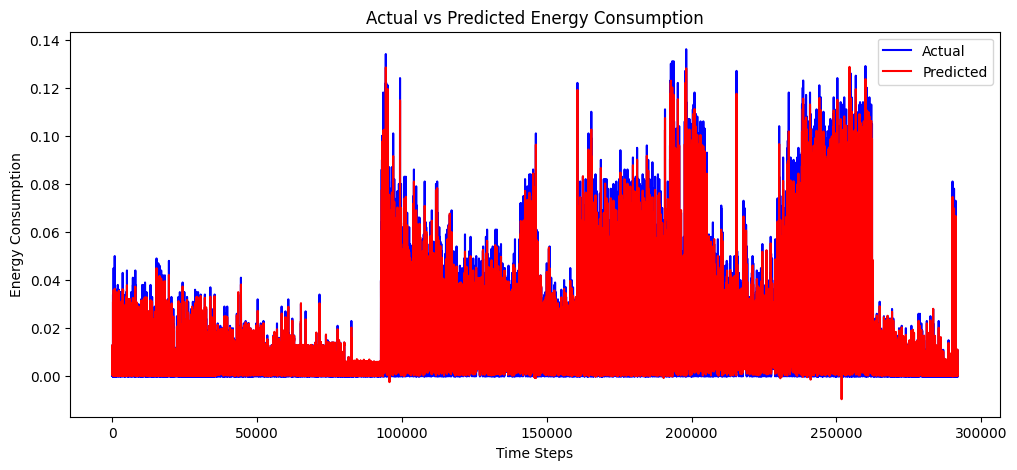

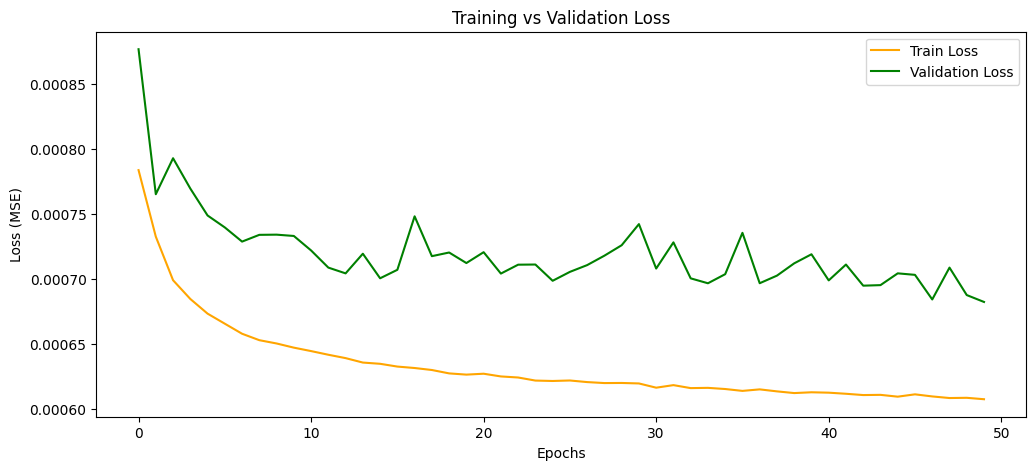

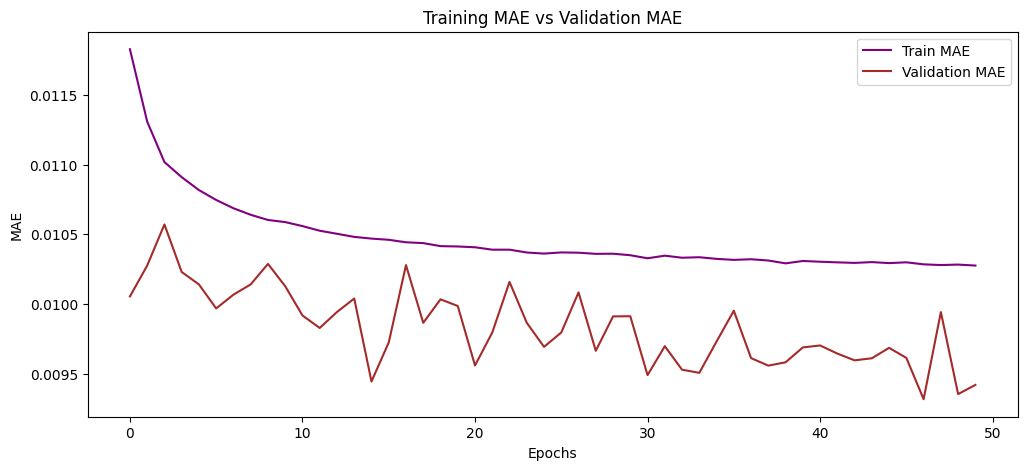

In [23]:
# ==========================================
#  Evaluate and Visualize
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1️⃣ Predictions and inverse scaling
y_pred = model.predict(X_test, batch_size=BATCH)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# 2️⃣ Metrics
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# 3️⃣ Plot Actual vs Predicted Energy Consumption
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(y_pred_inv, label='Predicted', color='red')
plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Time Steps")
plt.ylabel("Energy Consumption")
plt.legend()
plt.show()

# 4️⃣ Plot Training vs Validation Loss
plt.figure(figsize=(12,5))
plt.plot(history.history['loss'], label='Train Loss', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# 5️⃣ Plot Training MAE vs Validation MAE
plt.figure(figsize=(12,5))
plt.plot(history.history['mae'], label='Train MAE', color='purple')
plt.plot(history.history['val_mae'], label='Validation MAE', color='brown')
plt.title("Training MAE vs Validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()
